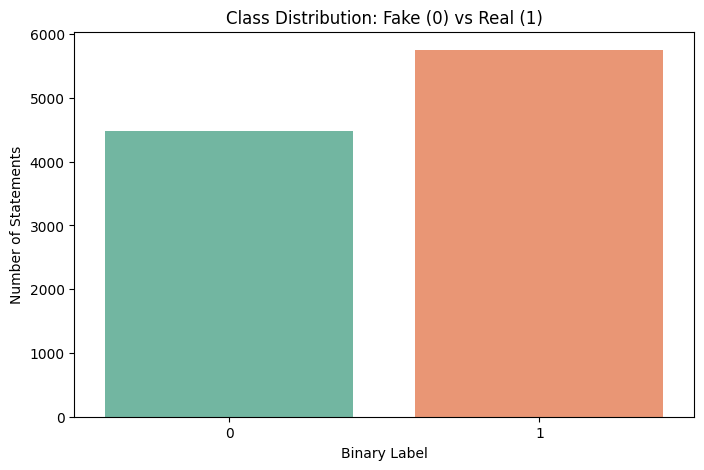

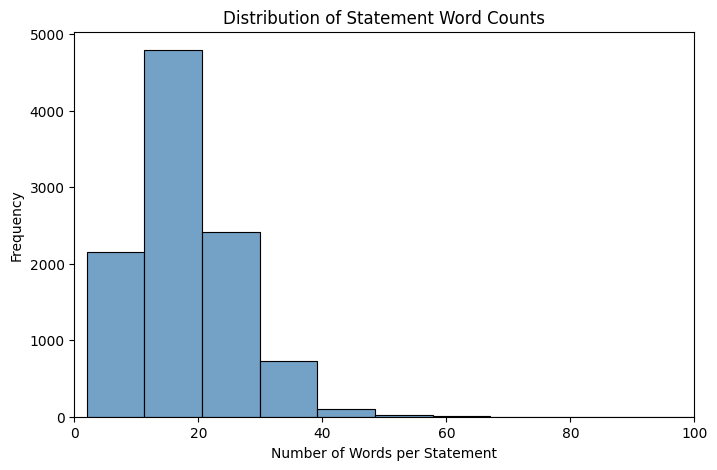

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the exact columns for the raw LIAR dataset
columns = [
    "id", "label", "statement", "subject", "speaker", "job_title", 
    "state", "party", "barely_true_counts", "false_counts", 
    "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "context"
]

# 2. Load the raw training data (using sep='\t' for TSV files)
train_df = pd.read_csv('../data/train.tsv', sep='\t', header=None, names=columns)

# 3. Define the binary mapping dictionary
# 0 = Fake (pants-fire, false, barely-true)
# 1 = Real (half-true, mostly-true, true)
label_mapping = {
    'pants-fire': 0,
    'false': 0,
    'barely-true': 0,
    'half-true': 1,
    'mostly-true': 1,
    'true': 1
}

# 4. Apply the mapping to create a new target column
train_df['binary_label'] = train_df['label'].map(label_mapping)

# Drop any rows where the actual text statement is missing
train_df = train_df.dropna(subset=['statement'])

# Calculate the word count for each statement to inform our DistilBERT max_length
train_df['word_count'] = train_df['statement'].apply(lambda x: len(str(x).split()))

# 5. Generate Checkpoint Screenshot 1: Class Balance (Warning Fixed!)
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='binary_label', hue='binary_label', palette='Set2', legend=False)
plt.title('Class Distribution: Fake (0) vs Real (1)')
plt.xlabel('Binary Label')
plt.ylabel('Number of Statements')
plt.show()

# 6. Generate Checkpoint Screenshot 2: Token Lengths
plt.figure(figsize=(8, 5))
sns.histplot(data=train_df, x='word_count', bins=50, color='steelblue')
plt.title('Distribution of Statement Word Counts')
plt.xlabel('Number of Words per Statement')
plt.ylabel('Frequency')
plt.xlim(0, 100) 
plt.show()